# Infer a Kd from flow data for individual clones (not libraries)

This notebook requires two input files (and the flow cytometry data):
- a run-list which specifies the antibody and antigen that are being tested, along with the flow cytometry data directory
- a concentrations list which specifies the concentrations used (in -log10(Molar)), along with 'well' assignments for looking up the flow cytometry data (we use a 96-well format for making these measurements, so the well numbers are automatically output when we export the flow cytometry fcs files to csvs)

For these low-throughput validation experiments, we ran several different antigen concentration configurations, which are labeled on the run-lists and concenstrations csvs as 'green' (for high affinity binders), 'yellow' (for medium-affinity binders), and 'red' (for low-affinity binders) - when running our notebooks for these experiments please make sure to use the correct color-coded pairs of these files to ensure the analysis runs properly

If you'd like to run a specific selected intermediate (labeled by 'shortname' in the run-list) from the library for BA.1 affinity using this notebook, here are the color codes for each intermediate (binary genotypes specifying the amino acid mutations in each sequence for these intermediates can be found in 'Omi32_low-throughput_affinities.csv', which is two folders upstream of this notebook - '../../'):

RED: 5173, 6396

YELLOW: 4034, 2205

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
import collections
import glob
import scipy.optimize
import scipy.stats

In [13]:
#get run list
run_list = pd.read_csv('run-list-yellow.csv')
run_list = run_list.dropna(axis=0, how='any')  # drop columns with any NaN values
run_list['shortname'] = run_list['shortname'].astype(int)
run_list['replicate'] = run_list['replicate'].astype(int)
run_list.head()

,row,directory,shortname,antigen,replicate
0,A,flow_data,4034,BA4,1
1,B,flow_data,4034,BA4,2
2,C,flow_data,2205,BA4,1
3,D,flow_data,2205,BA4,2


In [14]:
#get antigen concentrations
concentrations_list = pd.read_csv('concentrations-list-yellow.csv', index_col=[0])
cols = concentrations_list.index
concentrations_list

,BA4
well column,
1,14
2,11
3,10
4,9
5,8
6,7
7,6


In [15]:
# define functions for assigning csv to each mutant
def get_files(run_id):
    run_row = run_list.loc[run_id, :]
    wells = ['%c%02d' % (run_row['row'], i) for i in range(1, len(concentrations_list)+1)]

    def get_filename(well):
        search = os.path.join(run_row['directory'], f'*{well}*')
        filenames = glob.glob(search)
        if len(filenames) != 1:
            print(search, filenames)
            raise Exception(well)
        return filenames[0]

    return [pd.read_csv(get_filename(well)) for well in wells]


# #pin raw values (not log-transformed yet) to a safe detection threshold within linear detector range (based on average CST settings provided by UCSF Flow Core)
PIN_FLOOR = 100.0  # raw fluorescence floor; log10 floor = 2

def pin_fluor(run_id, floor=PIN_FLOOR, col='586_15 YG D-A'):
    run = get_files(run_id)

    for df in run:
        pe = df[col].astype(float).to_numpy()
        pe_pinned = np.maximum(pe, floor)
        df['PE_pinned'] = pe_pinned
        df['log_PE'] = np.log10(pe_pinned)

    run_row = run_list.loc[run_id, :]
    # optional: report how many values were pinned
    n_total = sum(len(df) for df in run)
    n_pinned = sum((df['PE_pinned'] == floor).sum() for df in run)
    print(run_row['shortname'], run_row['antigen'], f"pinned {n_pinned}/{n_total} < {floor}", sep='\t')

    return run


print('name', 'antigen', 'pin_stats', sep='\t')
runs = [pin_fluor(run_id) for run_id in run_list.index]
print(runs)


name	antigen	pin_stats
4034	BA4	pinned 10109/68211 < 100.0
4034	BA4	pinned 11557/70000 < 100.0
2205	BA4	pinned 28088/70000 < 100.0
2205	BA4	pinned 23128/70000 < 100.0
[[         FSC-A   FSC-H     FSC-W     SSC-A  SSC-H    SSC-W  530_30 Blue C-A  \
0     116144.0   68941  110408.0  100640.0  74795  88181.7          22045.3   
1      97551.8   71961   88842.0   56006.3  48559  75587.0          10960.0   
2     132670.0   87412   99467.7   82593.7  69538  77840.4          18155.3   
3     136395.0   90841   98400.6   76343.5  61947  80766.6          26126.1   
4     106167.0   71978   96665.5   69664.3  58620  77883.3          14917.3   
...        ...     ...       ...       ...    ...      ...              ...   
9995  135063.0   86303  102563.0  101891.0  81465  81967.9          23183.2   
9996   97467.6   66888   95497.5   60760.9  51098  77929.2          20271.2   
9997  113206.0   75737   97958.5  100152.0  82379  79674.9          29896.0   
9998  169483.0  107640  103189.0   91773.

## Fit fluorescence vs. [antigen] to get Kd

In [16]:
#https://elifesciences.org/articles/23156#s4

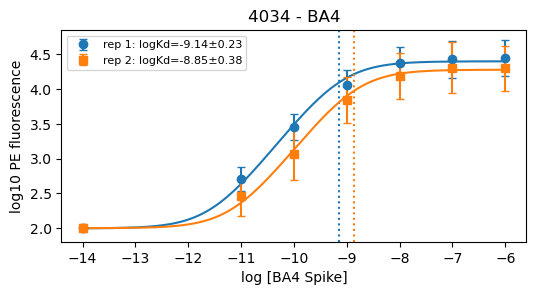

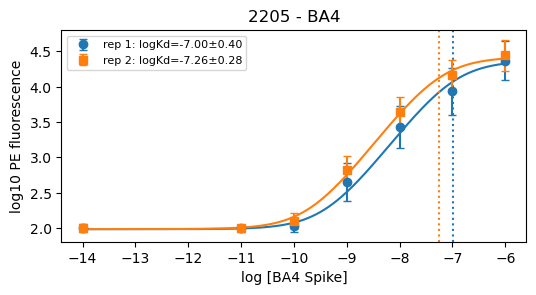

Done. Wrote KD/KD_err back into run_list and saved one PDF per shortname.


In [17]:
def sigmoid(c, Kd, A, B):
    return np.log10(A * (10**np.float64(c) / ((10**np.float64(c)) + (10**np.float64(Kd)))) + B)

def rms(y, yfit):
    return np.sqrt(np.sum((y - yfit)**2))

# init output columns
n_runs = run_list.shape[0]
run_list['KD'] = np.zeros(n_runs)
run_list['KD_err'] = np.zeros(n_runs)

# map run_id -> run data (1 dataframe per concentration)
run_by_id = {run_id: runs[i] for i, run_id in enumerate(run_list.index)}

# replicate styling (extend if you have >2 reps)
rep_colors = {
    1: "#1f77b4",
    2: "#ff7f0e",
    3: "#2ca02c",
    4: "#d62728",
    5: "#9467bd",
}
rep_markers = {1: "o", 2: "s", 3: "^", 4: "D", 5: "v"}

# plot one figure per set of antibody replicates (by shortname), overlay replicates
for shortname, grp in run_list.groupby('shortname', sort=False):

    # if a shortname spans multiple antigens, split further
    for antigen, grp2 in grp.groupby('antigen', sort=False):

        plt.figure(figsize=(6, 2.75))

        # concentrations for this antigen
        concs = (-concentrations_list[antigen]).copy()
        concs_plot = np.linspace(concs.min(), concs.max(), 300)

        # fit + plot each replicate
        for _, row in grp2.sort_values('replicate').iterrows():
            run_id = row.name  # index of run_list
            run = run_by_id[run_id]
            rep = int(row['replicate'])

            mean_log_fluor = [df['log_PE'].mean() for df in run]
            std_log_fluor  = [df['log_PE'].std()  for df in run]

            # curve_fit settings
            popt, pcov = scipy.optimize.curve_fit(
                sigmoid,
                concs,
                mean_log_fluor,
                p0=[(-9), 10**4, 10**2],
                sigma=std_log_fluor,
                absolute_sigma=True,
                bounds=[((-14), 1, 1), ((-5), 10**5, 10**5)],
                maxfev=400000
            )

            logKd = popt[0]
            logKd_err = float(np.sqrt(pcov[0][0])) if pcov.shape == (3,3) else np.nan

            # store results back into run_list row
            run_list.loc[run_id, 'KD'] = logKd
            run_list.loc[run_id, 'KD_err'] = logKd_err

            color = rep_colors.get(rep, "black")
            marker = rep_markers.get(rep, "o")

            plt.errorbar(
                concs, mean_log_fluor, yerr=std_log_fluor,
                fmt=marker, capsize=3, color=color,
                label=f"rep {rep}: logKd={logKd:.2f}±{logKd_err:.2f}"
            )
            plt.plot(concs_plot, sigmoid(concs_plot, *popt), color=color)
            plt.axvline(logKd, linestyle=":", color=color)

        plt.xlabel(f'log [{antigen} Spike]')
        plt.ylabel('log10 PE fluorescence')
        plt.legend(fontsize=8, loc='upper left')
        plt.title(f'{shortname} - {antigen}')
        plt.grid(False)

        # save per shortname+antigen
        outname = f"{shortname}_{antigen}_replicates.pdf"
        outname_png = f"{shortname}_{antigen}_replicates.png"
        #plt.savefig(f'images/{outname}', format="pdf", bbox_inches="tight")
        plt.savefig(f'images/{outname_png}', format="png", bbox_inches="tight", dpi=150)
        plt.show()

print("Done. Wrote KD/KD_err back into run_list and saved one PDF per shortname.")
